# Table of Contant

* [1. Loading Data](#1) <br>
* [2.Spliting Data as Train and Validation](#2) <br>
* [3.Creating Train Dataset from Train split](#3) <br>
* [4.Normalization / Feature Scaling](#4) <br>
* [5.Creating X_train and y_train from Train data](#5) <br>
* [6.Creating Simple RNN model](#6) <br>
* [7.Evaluating Model](#7) <br>
* [8.Creating Test Dataset from Validation Data](#8) <br>
* [9.Evaluating with Validation Data](#9) <br>
* [10.Creating LSTM model](#10) <br>
* [11.Evaluating LSTM model](#11) <br>
* [12.Future price prediction](#12) <br>


<a id="1"></a>
## 1.Loading Data

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('/content/RELIANCE.NS.csv')

In [3]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2023-03-15,2108.223633,2121.330078,2055.889404,2064.796387,2057.528320,10864277
1,2023-03-16,2070.288330,2080.441162,2032.629883,2054.504883,2047.272949,9181579
2,2023-03-17,2071.903564,2078.549072,2042.321411,2051.920654,2044.697876,17007106
3,2023-03-20,2044.444336,2049.059326,2012.139282,2031.753052,2024.601196,9762294
4,2023-03-21,2048.090088,2098.901367,2046.290283,2094.932373,2087.558105,10700180


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       247 non-null    object 
 1   Open       247 non-null    float64
 2   High       247 non-null    float64
 3   Low        247 non-null    float64
 4   Close      247 non-null    float64
 5   Adj Close  247 non-null    float64
 6   Volume     247 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 13.6+ KB


<a id="2"></a>
## 2.Spliting Data as Train and Validation

In [5]:
length_data = len(data)     # rows that data has
split_ratio = 0.7           # %70 train + %30 validation
length_train = round(length_data * split_ratio)
length_validation = length_data - length_train
print("Data length :", length_data)
print("Train data length :", length_train)
print("Validation data lenth :", length_validation)

Data length : 247
Train data length : 173
Validation data lenth : 74


In [6]:
train_data = data[:length_train].iloc[:,:2]
train_data['Date'] = pd.to_datetime(train_data['Date'])  # converting to date time object
train_data

,Date,Open
0,2023-03-15,2108.223633
1,2023-03-16,2070.288330
2,2023-03-17,2071.903564
3,2023-03-20,2044.444336
4,2023-03-21,2048.090088
...,...,...
168,2023-11-21,2366.000000
169,2023-11-22,2375.000000
170,2023-11-23,2388.199951
171,2023-11-24,2391.600098


In [7]:
validation_data = data[length_train:].iloc[:,:2]
validation_data['Date'] = pd.to_datetime(validation_data['Date'])  # converting to date time object
validation_data

,Date,Open
173,2023-11-29,2408.000000
174,2023-11-30,2394.699951
175,2023-12-01,2378.000000
176,2023-12-04,2450.000000
177,2023-12-05,2439.000000
...,...,...
242,2024-03-11,2978.000000
243,2024-03-12,2933.199951
244,2024-03-13,2959.550049
245,2024-03-14,2879.399902


<a id="3"></a>
## 3.Creating Train Dataset from Train split

* We will get Open column as our dataset
* Dataset to be converted to array by adding `.values`

In [8]:
dataset_train = train_data.Open.values
dataset_train.shape

(173,)

In [9]:
# Change 1d array to 2d array
# Changing shape from (1692,) to (1692,1)
dataset_train = np.reshape(dataset_train, (-1,1))
dataset_train.shape

(173, 1)

#### <a id="4"></a>
## 4.Normalization / Feature Scaling

* Dataset values will be in between 0 and 1 after scaling

In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))


# scaling dataset
dataset_train_scaled = scaler.fit_transform(dataset_train)

dataset_train_scaled.shape

(173, 1)

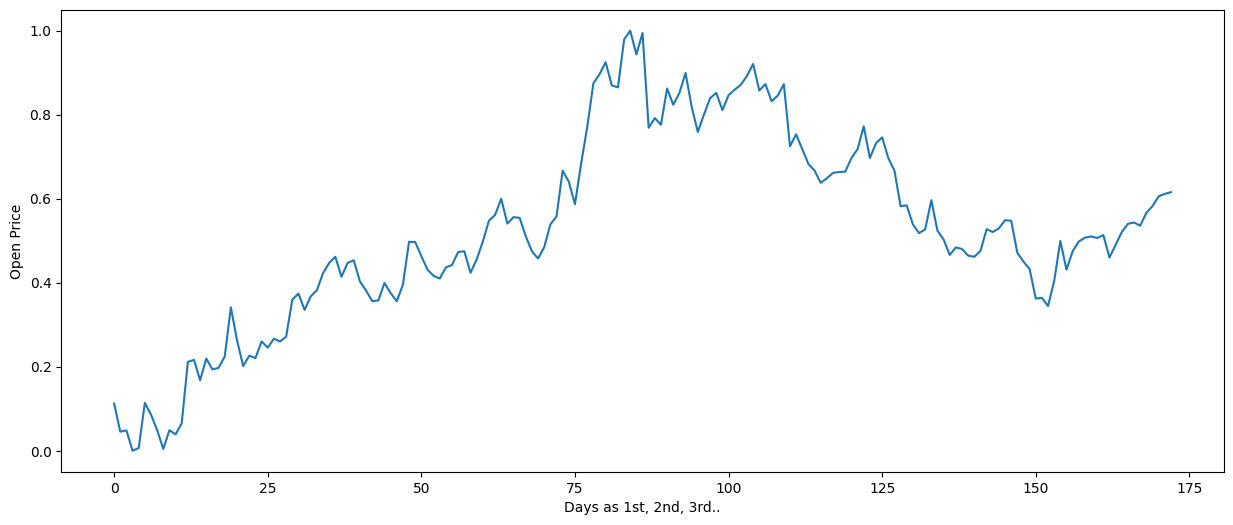

In [11]:
plt.subplots(figsize = (15,6))
plt.plot(dataset_train_scaled)
plt.xlabel("Days as 1st, 2nd, 3rd..")
plt.ylabel("Open Price")
plt.show()

<a id="5"></a>
## 5.Creating X_train and y_train from Train data

![image.png](attachment:image.png)

* We have train data composed of stock open prices over days
* So, it has 1184 prices corresponding 1184 days
* My aim is to predict the open price of the next day.
* I can use a time step of 50 days.
* I will pick first 50 open prices (0 to 50), 1st 50 price will be in X_train data
* Then predict the price of 51th day; and 51th price will be in y_train data
* Again, i will pick prices from 1 to 51, those will be in X_train data
* Then predict the next days price, 52nd price will be in y_train data

In [12]:
X_train = []
y_train = []

time_step = 50

for i in range(time_step, length_train):
    X_train.append(dataset_train_scaled[i-time_step:i,0])
     y_train.append(dataset_train_scaled[i,0])

# convert list to array
X_train, y_train = np.array(X_train), np.array(y_train)


In [13]:
print("Shape of X_train before reshape :",X_train.shape)
print("Shape of y_train before reshape :",y_train.shape)

Shape of X_train before reshape : (123, 50)
Shape of y_train before reshape : (123,)


## Reshape

In [14]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],1))
y_train = np.reshape(y_train, (y_train.shape[0],1))

print("Shape of X_train after reshape :",X_train.shape)
print("Shape of y_train after reshape :",y_train.shape)

Shape of X_train after reshape : (123, 50, 1)
Shape of y_train after reshape : (123, 1)


* Shape of X_train : 1134 x 50 x 1
* That means we have 1134 rows, each row has 50 rows and 1 column
* Lets check the first row: it has 50 rows (open prices of 49 days)

In [15]:
X_train[0]

array([[0.11235776],
       [0.04552846],
       [0.04837396],
       [0.        ],
       [0.00642259],
       [0.11382094],
       [0.0861788 ],
       [0.04918684],
       [0.00406503],
       [0.0487804 ],
       [0.03902415],
       [0.06504054],
       [0.21138218],
       [0.21625988],
       [0.16772334],
       [0.21951225],
       [0.19349586],
       [0.19731681],
       [0.22438994],
       [0.34138197],
       [0.26341453],
       [0.20170722],
       [0.2261787 ],
       [0.22056899],
       [0.26016258],
       [0.24552821],
       [0.26666647],
       [0.26016258],
       [0.27154459],
       [0.35967473],
       [0.37398353],
       [0.33520324],
       [0.36747964],
       [0.38211359],
       [0.42276436],
       [0.44715456],
       [0.46170722],
       [0.41430871],
       [0.44699199],
       [0.45365845],
       [0.40325186],
       [0.381382  ],
       [0.35617892],
       [0.35772339],
       [0.3994309 ],
       [0.37544714],
       [0.35593506],
       [0.395

* Check the first item in y_train
* It is the price of 50th day

In [16]:
y_train[0]

array([0.4634147])

<a id="6"></a>
## 6.Creating RNN model

In [17]:
# importing libraries
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import Dropout

# initializing the RNN
regressor = Sequential()

# adding first RNN layer and dropout regulatization
regressor.add(
    SimpleRNN(units = 50,
              activation = "tanh",
              return_sequences = True,
              input_shape = (X_train.shape[1],1))
             )

regressor.add(
    Dropout(0.2)
             )


# adding second RNN layer and dropout regulatization

regressor.add(
    SimpleRNN(units = 50,
              activation = "tanh",
              return_sequences = True)
             )

regressor.add(
    Dropout(0.2)
             )

# adding third RNN layer and dropout regulatization

regressor.add(
    SimpleRNN(units = 50,
              activation = "tanh",
              return_sequences = True)
             )

regressor.add(
    Dropout(0.2)
             )

# adding fourth RNN layer and dropout regulatization

regressor.add(
    SimpleRNN(units = 50)
             )

regressor.add(
    Dropout(0.2)
             )

# adding the output layer
regressor.add(Dense(units = 1))

# compiling RNN
regressor.compile(
    optimizer = "adam",
    loss = "mean_squared_error",
    metrics = ["accuracy"])

# fitting the RNN
history = regressor.fit(X_train, y_train, epochs = 50, batch_size = 32)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.0000e+00 - loss: 0.7574
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.0000e+00 - loss: 0.5067
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0147 - loss: 0.3592
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.0000e+00 - loss: 0.4602
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0033 - loss: 0.4106    
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.0033 - loss: 0.3905
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.0000e+00 - loss: 0.4540
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.0000e+00 - loss: 0.4050
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.0147 - loss: 0.3884
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.0033 - loss: 0.3655
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0033 - loss: 0.3679    
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accur

<a id="7"></a>
## 7.Evaluating Model

In [18]:
# Losses
history.history["loss"]

[0.8271771669387817,
 0.45524534583091736,
 0.36747974157333374,
 0.46138283610343933,
 0.411094605922699,
 0.3923667371273041,
 0.4697495698928833,
 0.3880346715450287,
 0.37856510281562805,
 0.3715292811393738,
 0.3737335801124573,
 0.30843305587768555,
 0.24168208241462708,
 0.29792964458465576,
 0.29738789796829224,
 0.3004501461982727,
 0.2689497172832489,
 0.2621082663536072,
 0.26341190934181213,
 0.22165903449058533,
 0.2553398013114929,
 0.2121179848909378,
 0.26663413643836975,
 0.18178458511829376,
 0.19134141504764557,
 0.24710920453071594,
 0.1930629163980484,
 0.21333514153957367,
 0.21149137616157532,
 0.20905034244060516,
 0.1878231018781662,
 0.216615691781044,
 0.16622577607631683,
 0.19079943001270294,
 0.15683819353580475,
 0.21256442368030548,
 0.2042534351348877,
 0.1977817565202713,
 0.17182186245918274,
 0.16910308599472046,
 0.16744694113731384,
 0.19627384841442108,
 0.18695341050624847,
 0.14475584030151367,
 0.11425653100013733,
 0.1505928784608841,
 0.13125

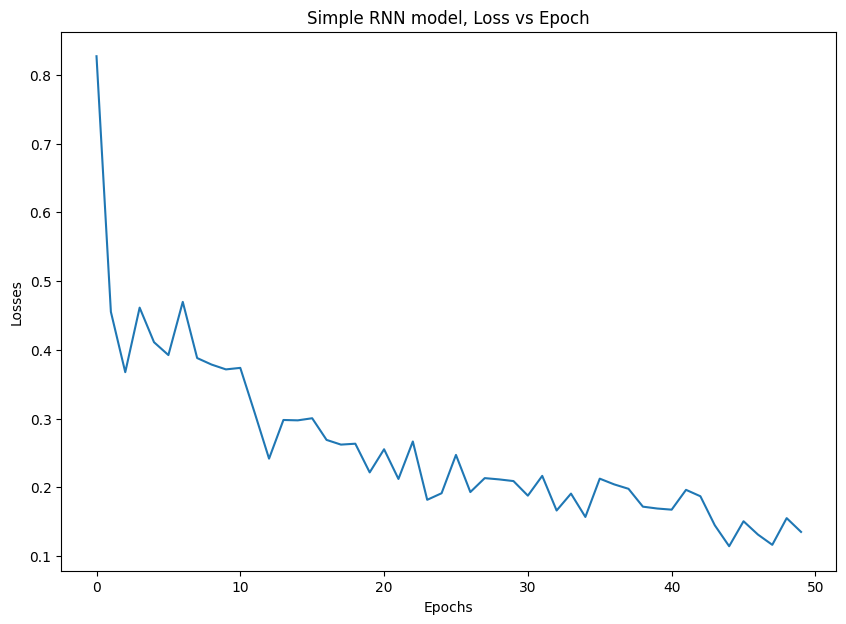

In [19]:
# Plotting Loss vs Epochs
plt.figure(figsize =(10,7))
plt.plot(history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("Simple RNN model, Loss vs Epoch")
plt.show()

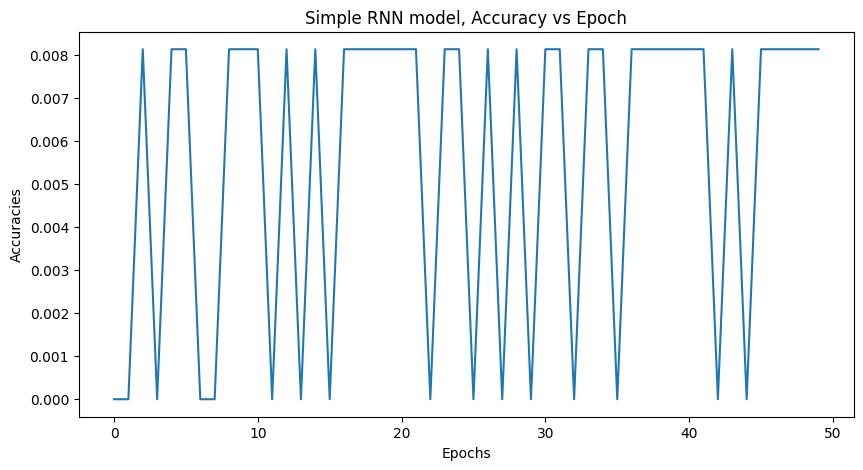

In [20]:
# Plotting Accuracy vs Epochs
plt.figure(figsize =(10,5))
plt.plot(history.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracies")
plt.title("Simple RNN model, Accuracy vs Epoch")
plt.show()

## Model predictions for train data

In [21]:
y_pred = regressor.predict(X_train)  # predictions
y_pred = scaler.inverse_transform(y_pred) # scaling back from 0-1 to original
y_pred.shape

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 342ms/step


(123, 1)

In [22]:
y_train = scaler.inverse_transform(y_train) # scaling back from 0-1 to original
y_train.shape

(123, 1)

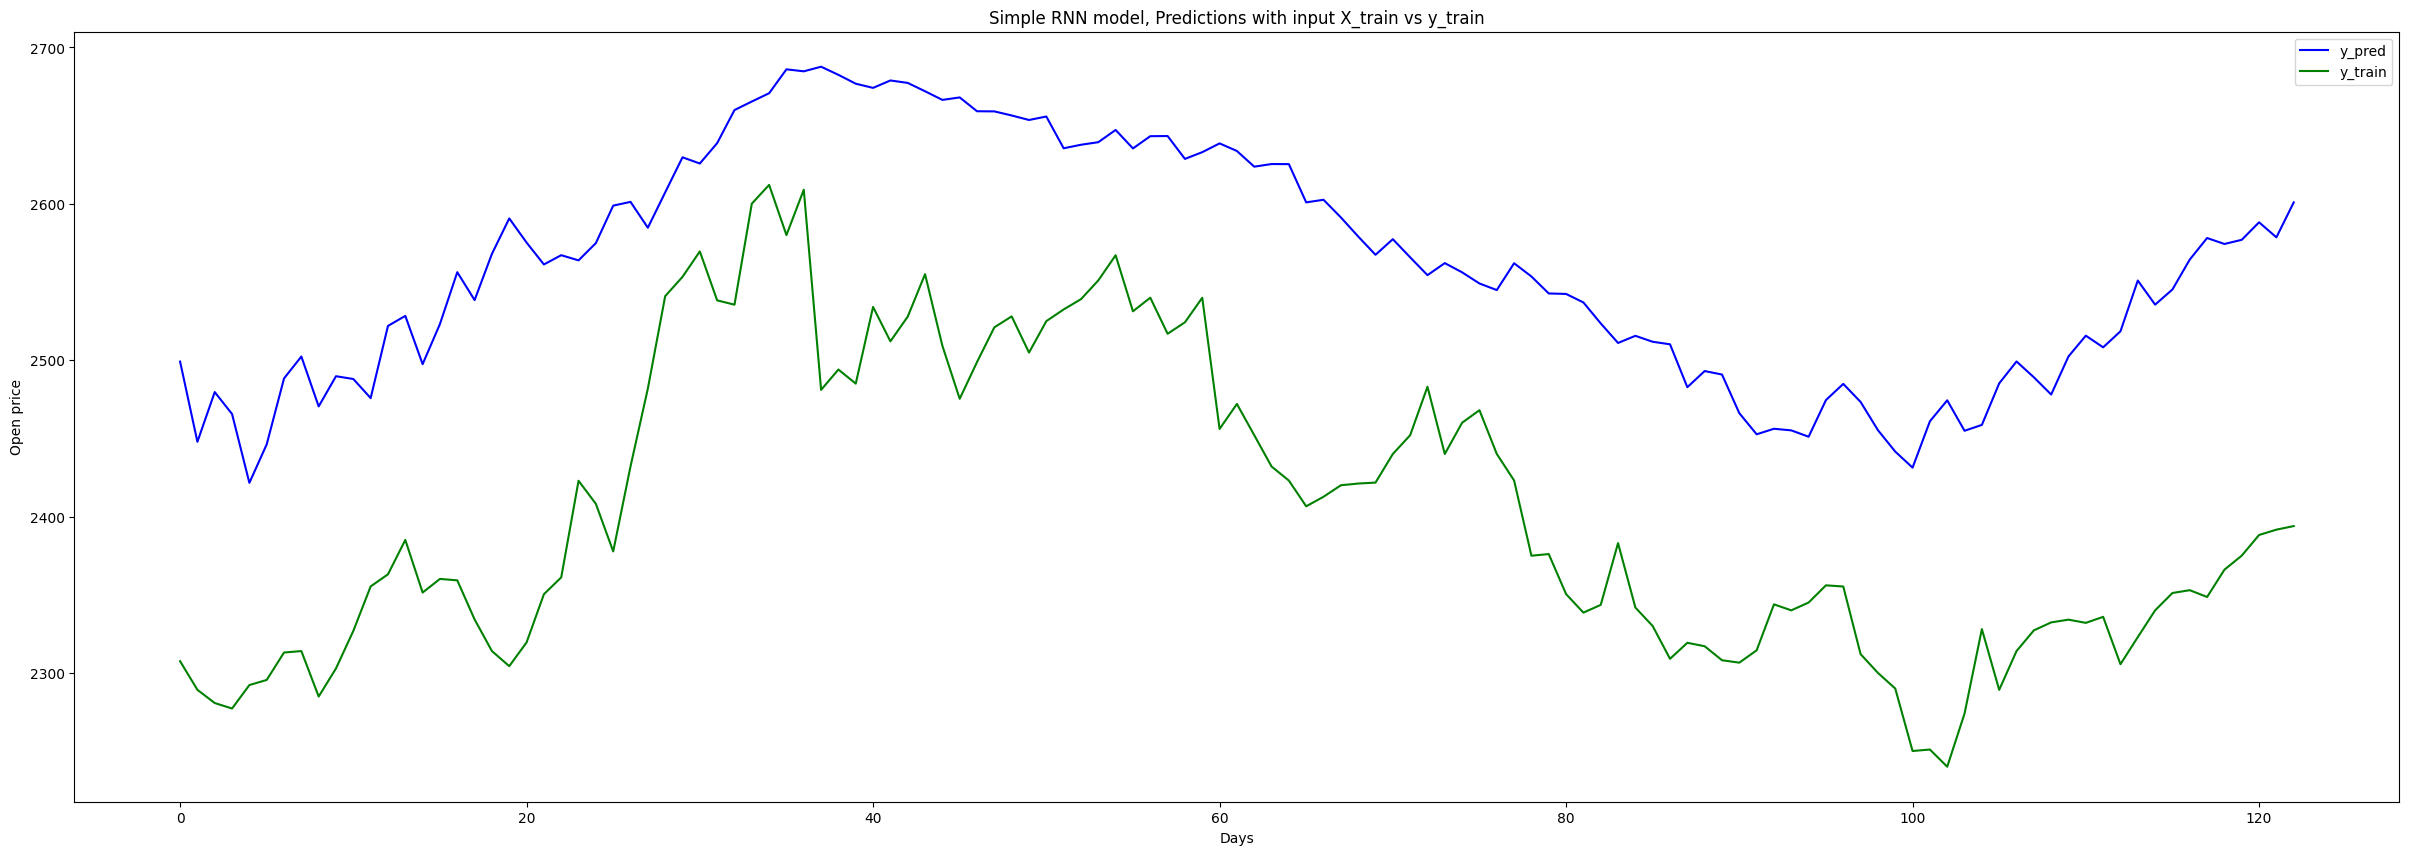

In [23]:
# visualisation
plt.figure(figsize = (30,10))
plt.plot(y_pred, color = "b", label = "y_pred" )
plt.plot(y_train, color = "g", label = "y_train")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("Simple RNN model, Predictions with input X_train vs y_train")
plt.legend()
plt.show()


<a id="8"></a>
## 8.Creating Test Dataset from Validation Data

### Converting array and scaling

In [24]:
dataset_validation = validation_data.Open.values  # getting "open" column and converting to array
dataset_validation = np.reshape(dataset_validation, (-1,1))  # converting 1D to 2D array
scaled_dataset_validation =  scaler.fit_transform(dataset_validation)  # scaling open values to between 0 and 1
print("Shape of scaled validation dataset :",scaled_dataset_validation.shape)

Shape of scaled validation dataset : (74, 1)


### Creating X_test and y_test

In [25]:
# Creating X_test and y_test
X_test = []
y_test = []

for i in range(time_step, length_validation):
    X_test.append(scaled_dataset_validation[i-time_step:i,0])
    y_test.append(scaled_dataset_validation[i,0])

### Converting to array

In [26]:
# Converting to array
X_test, y_test = np.array(X_test), np.array(y_test)

In [27]:
print("Shape of X_test before reshape :",X_test.shape)
print("Shape of y_test before reshape :",y_test.shape)

Shape of X_test before reshape : (24, 50)
Shape of y_test before reshape : (24,)


### Reshape

In [28]:
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))  # reshape to 3D array
y_test = np.reshape(y_test, (-1,1))  # reshape to 2D array

In [29]:
print("Shape of X_test after reshape :",X_test.shape)
print("Shape of y_test after reshape :",y_test.shape)

Shape of X_test after reshape : (24, 50, 1)
Shape of y_test after reshape : (24, 1)


<a id="9"></a>
## 9.Evaluating with Validation Data

In [30]:
# predictions with X_test data
y_pred_of_test = regressor.predict(X_test)
# scaling back from 0-1 to original
y_pred_of_test = scaler.inverse_transform(y_pred_of_test)
print("Shape of y_pred_of_test :",y_pred_of_test.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Shape of y_pred_of_test : (24, 1)


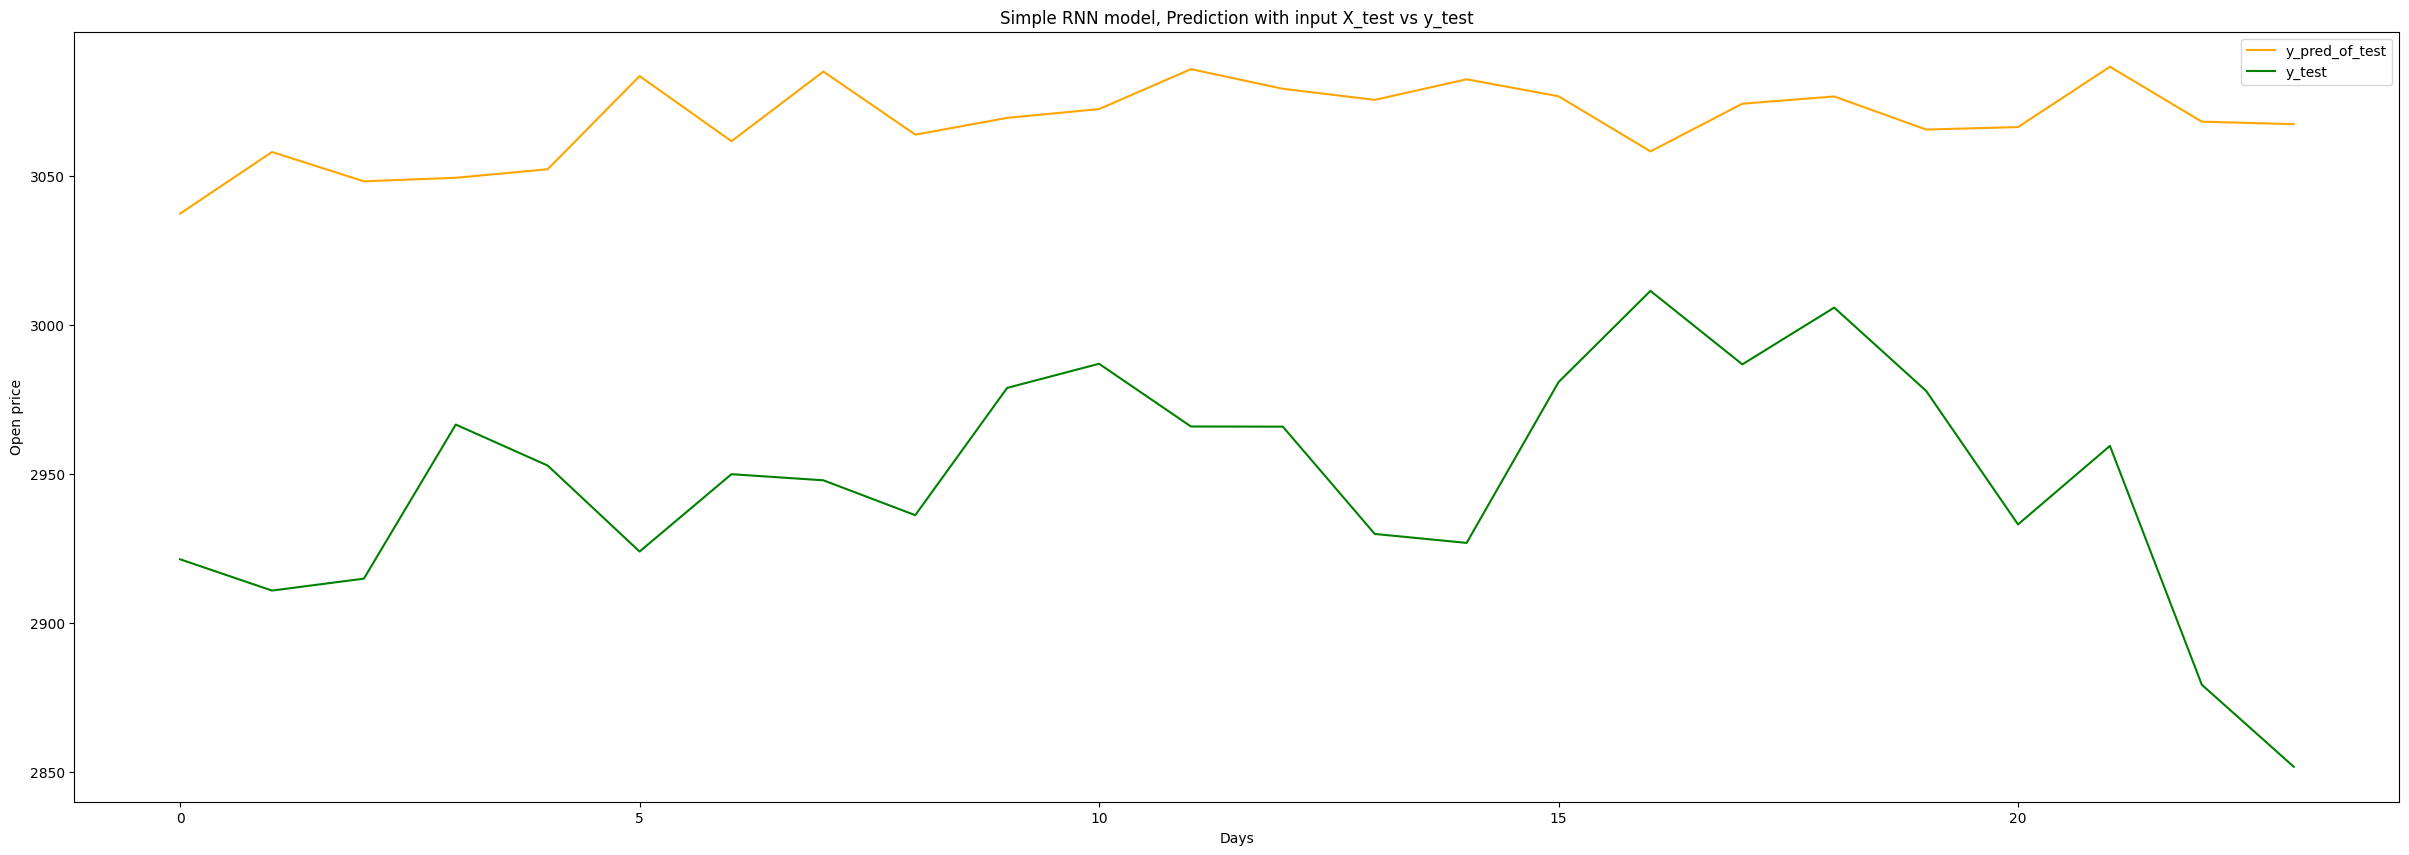

In [31]:
# visualisation
plt.figure(figsize = (30,10))
plt.plot(y_pred_of_test, label = "y_pred_of_test", c = "orange")
plt.plot(scaler.inverse_transform(y_test), label = "y_test", c = "g")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("Simple RNN model, Prediction with input X_test vs y_test")
plt.legend()
plt.show()

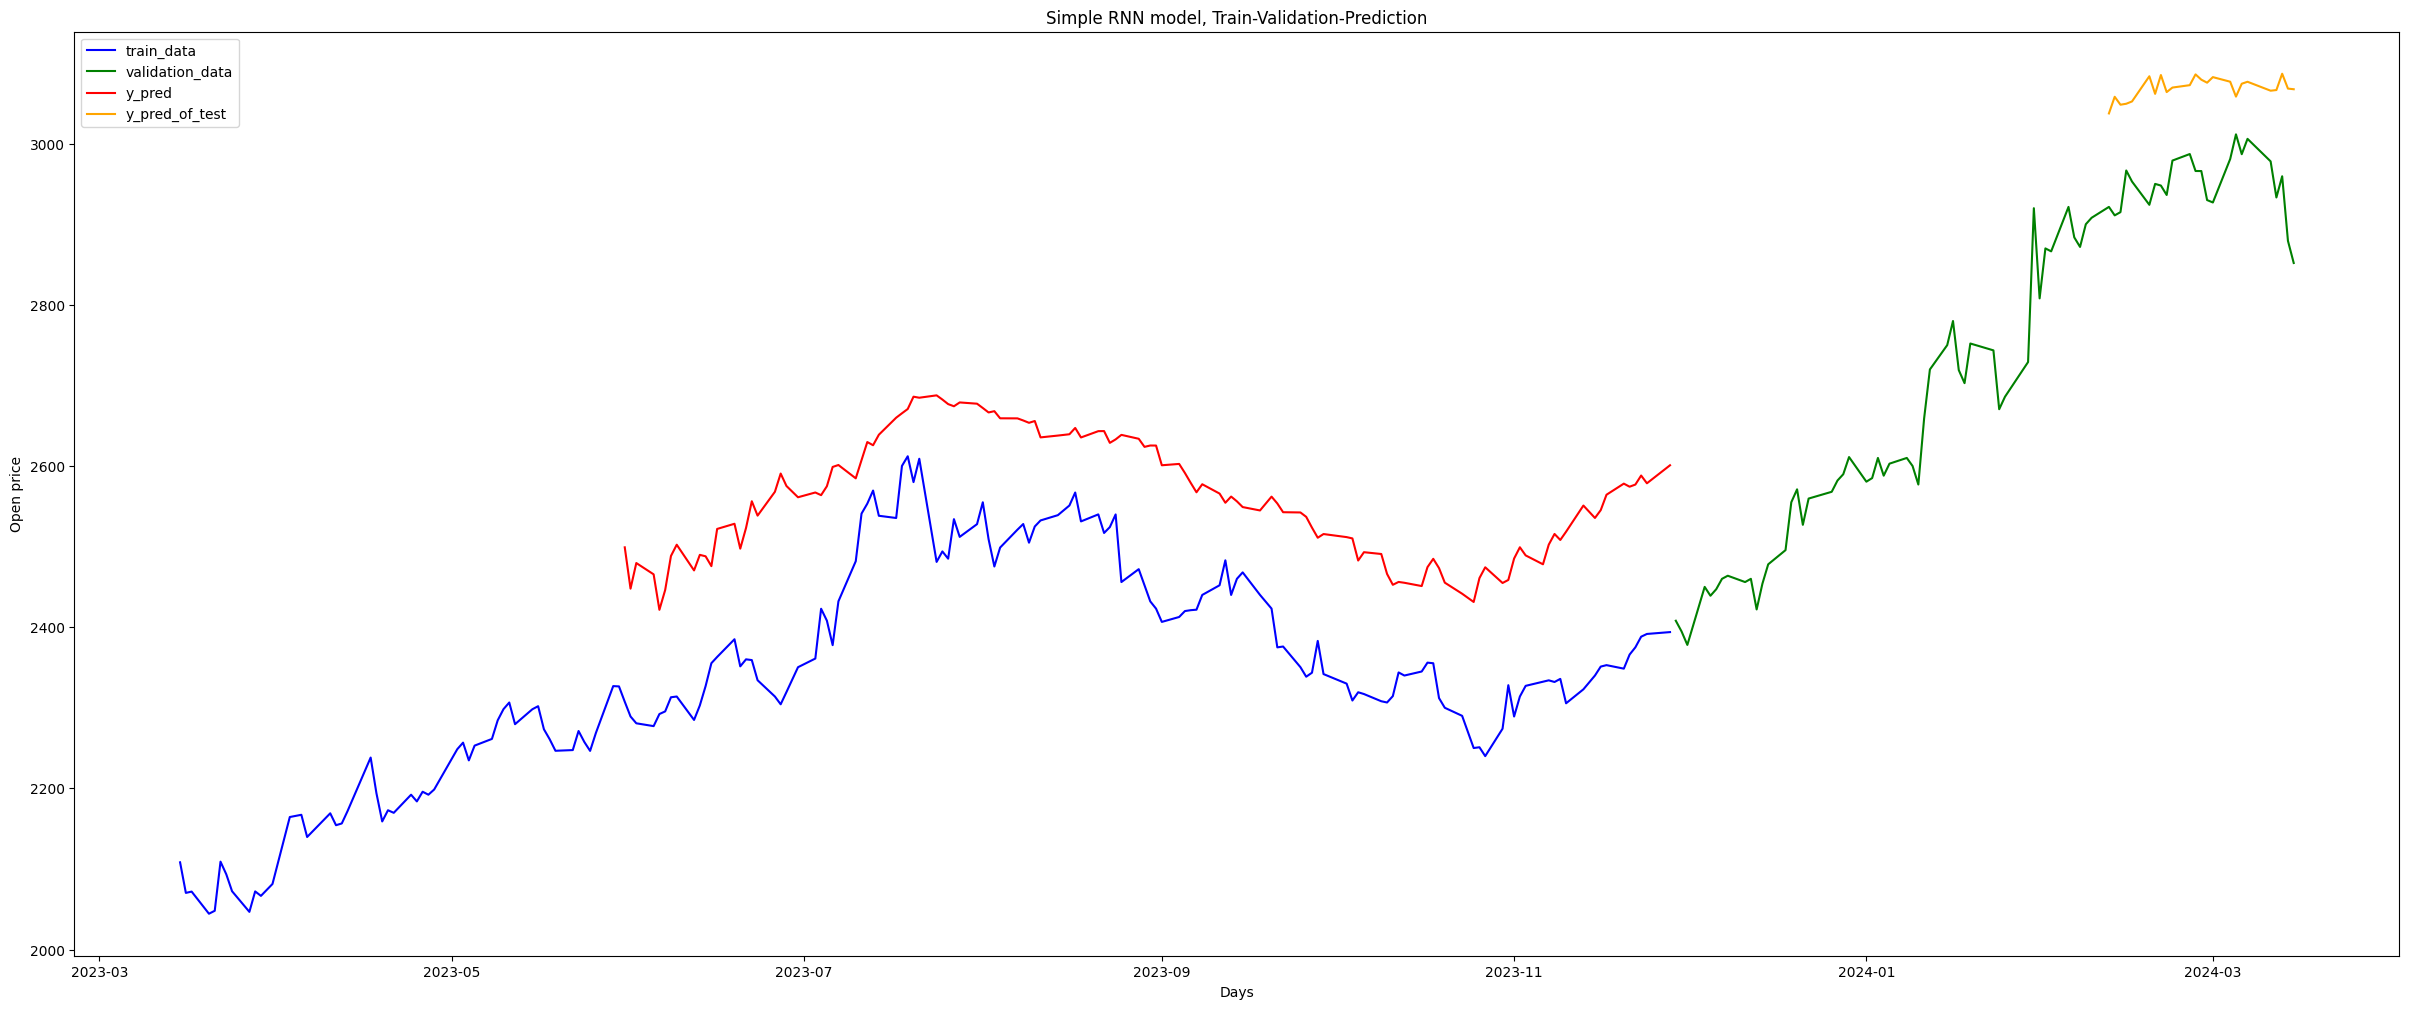

In [32]:
# Visualisation
plt.subplots(figsize =(30,12))
plt.plot(train_data.Date, train_data.Open, label = "train_data", color = "b")
plt.plot(validation_data.Date, validation_data.Open, label = "validation_data", color = "g")
plt.plot(train_data.Date.iloc[time_step:], y_pred, label = "y_pred", color = "r")
plt.plot(validation_data.Date.iloc[time_step:], y_pred_of_test, label = "y_pred_of_test", color = "orange")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("Simple RNN model, Train-Validation-Prediction")
plt.legend()
plt.show()

<a id="10"></a>
## 10.Creating LSTM Model

In [33]:
y_train = scaler.fit_transform(y_train)

In [34]:
from keras.layers import LSTM

model_lstm = Sequential()
model_lstm.add(
    LSTM(64,return_sequences=True,input_shape = (X_train.shape[1],1))) #64 lstm neuron block
model_lstm.add(
    LSTM(64, return_sequences= False))
model_lstm.add(Dense(32))
model_lstm.add(Dense(1))
model_lstm.compile(loss = "mean_squared_error", optimizer = "adam", metrics = ["accuracy"])
history2 = model_lstm.fit(X_train, y_train, epochs = 10, batch_size = 10)


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.0039 - loss: 0.1213
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.0141 - loss: 0.0491
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.0232 - loss: 0.0388
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0057 - loss: 0.0332
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.0089 - loss: 0.0263
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.0150 - loss: 0.0214
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0228 - loss: 0.0235
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.0303 - loss: 0.0199
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.0072 - loss: 0.0233
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.0201 - loss: 0.0204


<a id="11"></a>
## 11.Evaluating LSTM Model

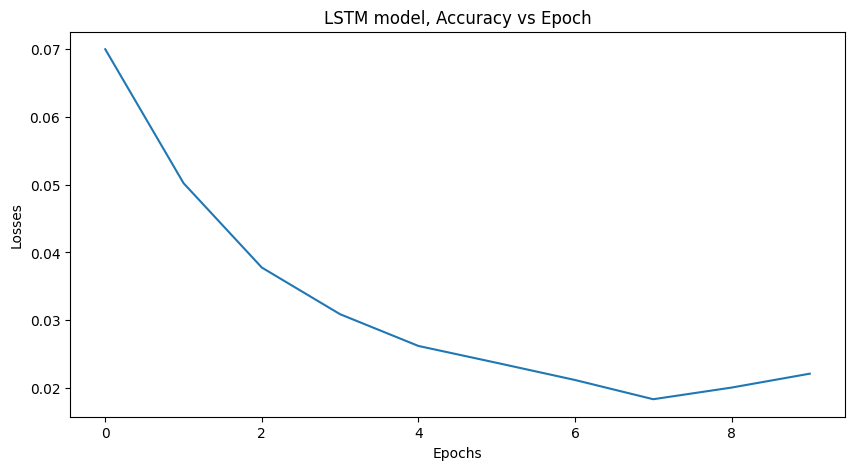

In [35]:
plt.figure(figsize =(10,5))
plt.plot(history2.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("LSTM model, Accuracy vs Epoch")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step


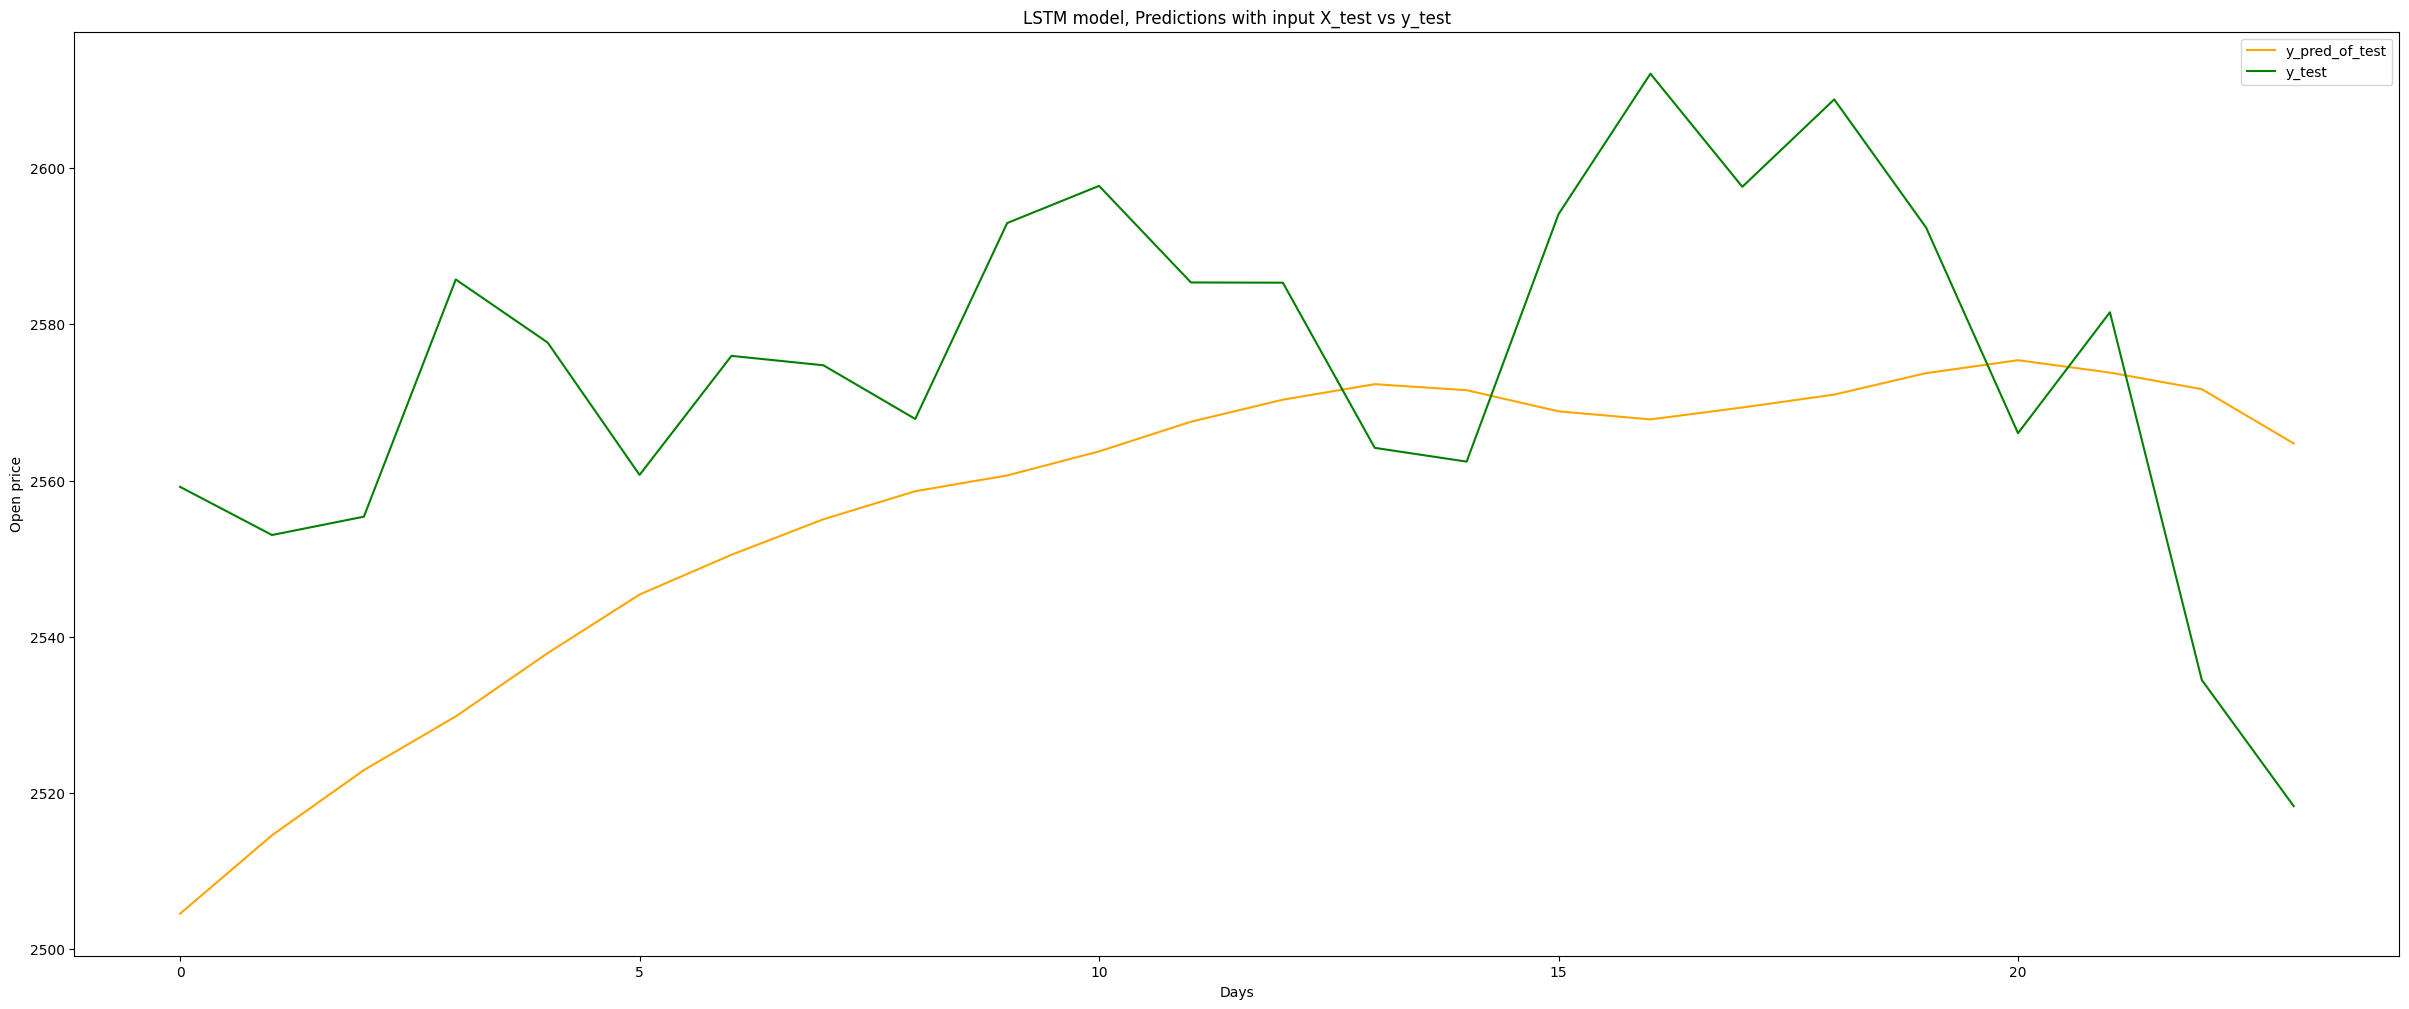

In [36]:
plt.subplots(figsize =(30,12))
plt.plot(scaler.inverse_transform(model_lstm.predict(X_test)), label = "y_pred_of_test", c = "orange" )
plt.plot(scaler.inverse_transform(y_test), label = "y_test", color = "g")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("LSTM model, Predictions with input X_test vs y_test")
plt.legend()
plt.show()

<a id="12"></a>
## 12.Future price prediction

* Which day is the last day in our data?

In [37]:
data.iloc[-1]

,246
Date,2024-03-15
Open,2851.899902
High,2866.449951
Low,2825.800049
Close,2836.449951
Adj Close,2836.449951
Volume,9610095


* We can predict the open price for the day after 3/17/2017--> for  3/18/2017.
* We will use last 50 days Open price as input of our model for this prediction
* Let us prepare it:

In [38]:
X_input = data.iloc[-time_step:].Open.values               # getting last 50 rows and converting to array
X_input = scaler.fit_transform(X_input.reshape(-1,1))      # converting to 2D array and scaling
X_input = np.reshape(X_input, (1,50,1))                    # reshaping : converting to 3D array
print("Shape of X_input :", X_input.shape)
X_input

Shape of X_input : (1, 50, 1)


array([[[0.07594062],
        [0.02531354],
        [0.05960165],
        [0.07594062],
        [0.05292831],
        [0.        ],
        [0.18870093],
        [0.32861589],
        [0.39811295],
        [0.4670347 ],
        [0.32677479],
        [0.28949496],
        [0.40271541],
        [0.38315494],
        [0.21504991],
        [0.25060382],
        [0.3497871 ],
        [0.78909185],
        [0.53158434],
        [0.67426065],
        [0.66586139],
        [0.79277404],
        [0.7057874 ],
        [0.67851816],
        [0.74329758],
        [0.76170743],
        [0.79277404],
        [0.76861112],
        [0.77781604],
        [0.89678957],
        [0.86514764],
        [0.79875747],
        [0.8584743 ],
        [0.85375666],
        [0.82683237],
        [0.92509482],
        [0.94373502],
        [0.89529399],
        [0.89517882],
        [0.81233451],
        [0.80543081],
        [0.92958211],
        [1.        ],
        [0.94327432],
        [0.98711288],
        [0

In [39]:
lstm_y_pred = regressor.predict(X_train)  # predictions
lstm_y_pred = scaler.inverse_transform(lstm_y_pred) # scaling back from 0-1 to original
lstm_y_pred.shape

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


(123, 1)

In [40]:
# predictions with X_test data
lstm_y_pred_of_test = regressor.predict(X_test)
# scaling back from 0-1 to original
lstm_y_pred_of_test = scaler.inverse_transform(lstm_y_pred_of_test)
print("Shape of lstm_y_pred_of_test :",y_pred_of_test.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Shape of lstm_y_pred_of_test : (24, 1)


# LSTM Prediction

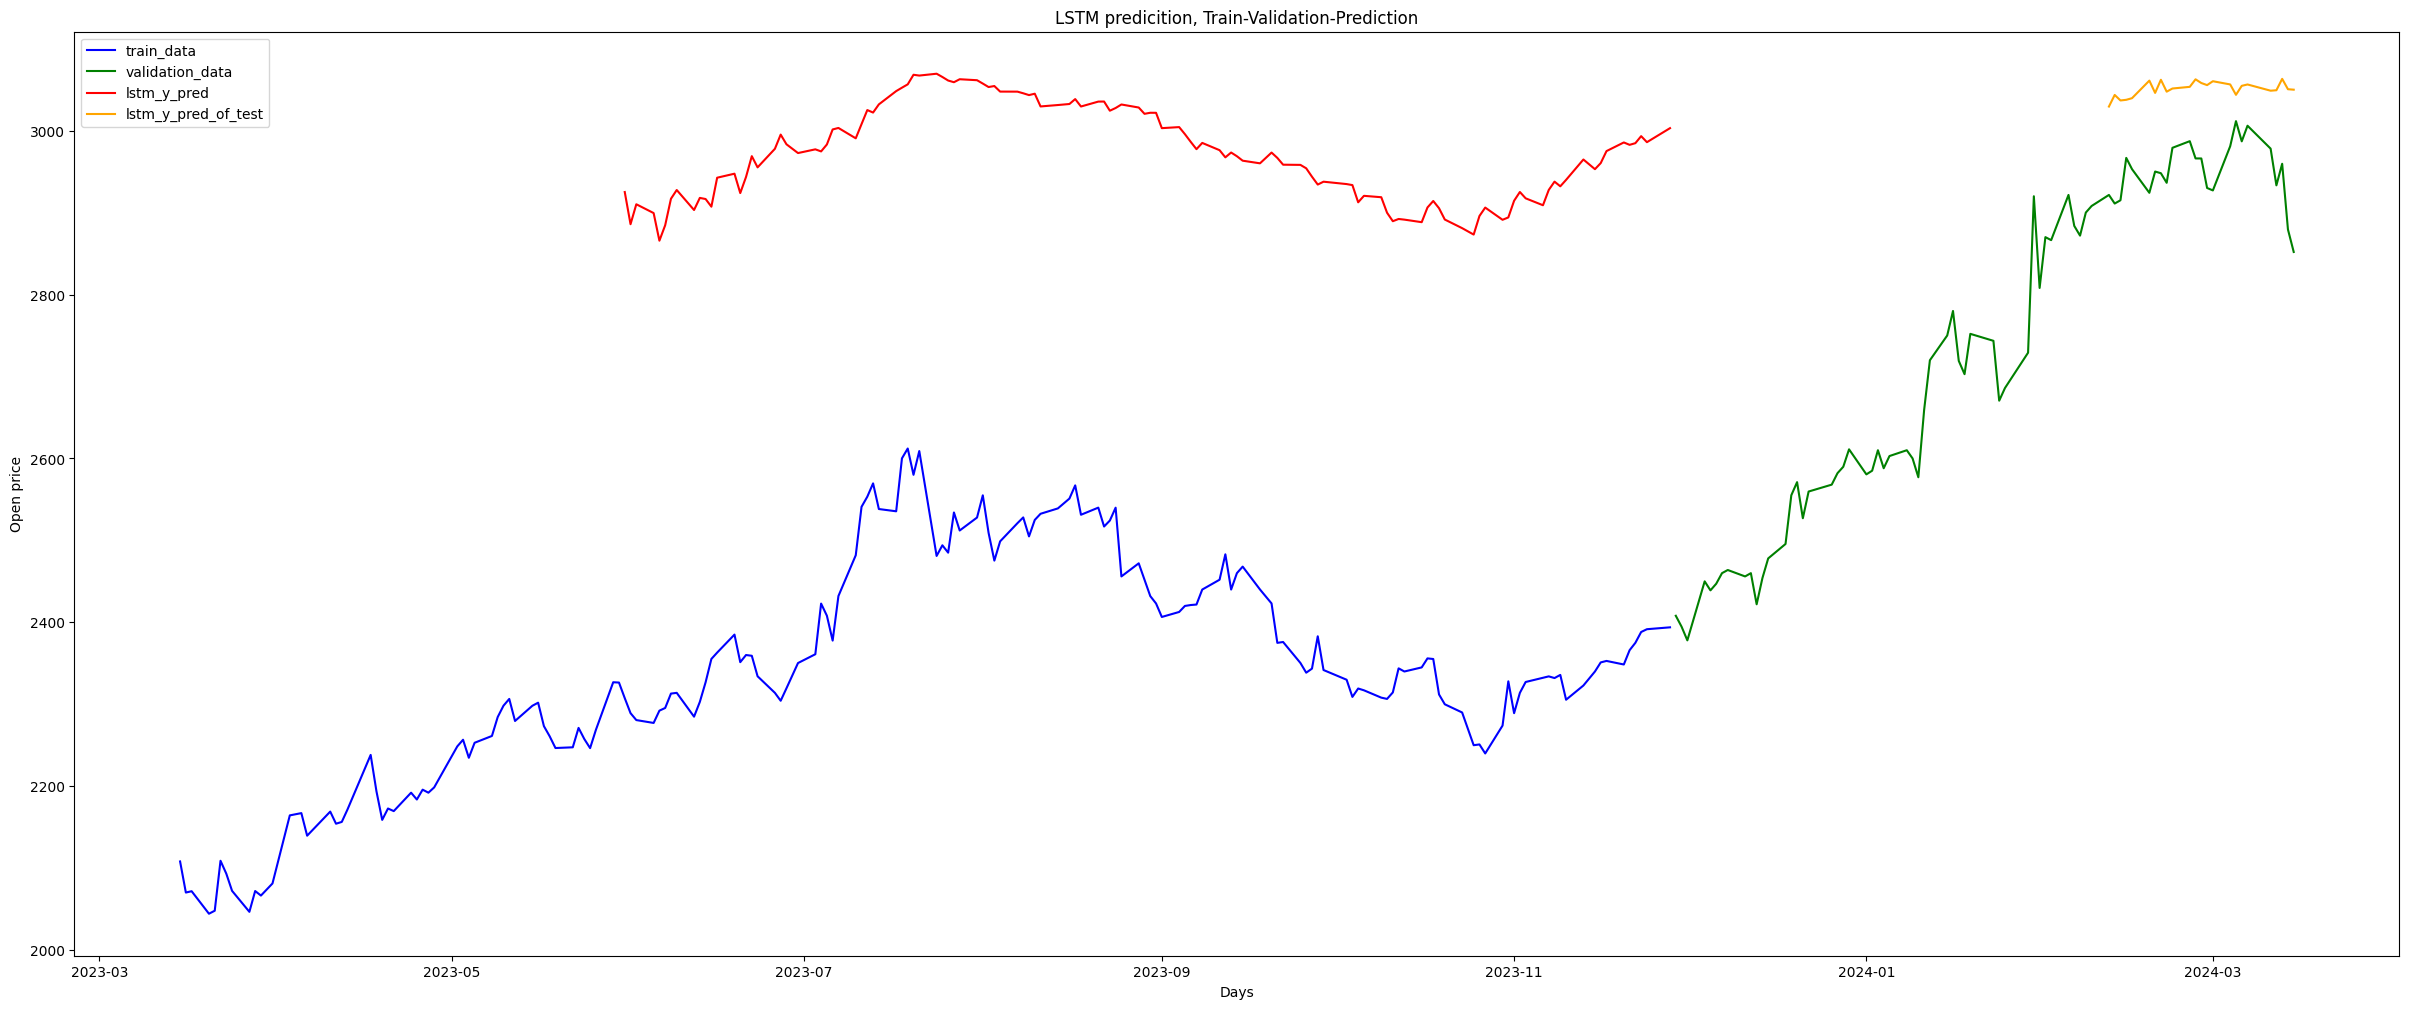

In [41]:
# Visualisation
plt.subplots(figsize =(30,12))
plt.plot(train_data.Date, train_data.Open, label = "train_data", color = "b")
plt.plot(validation_data.Date, validation_data.Open, label = "validation_data", color = "g")
plt.plot(train_data.Date.iloc[time_step:], lstm_y_pred, label = "lstm_y_pred", color = "r")
plt.plot(validation_data.Date.iloc[time_step:], lstm_y_pred_of_test, label = "lstm_y_pred_of_test", color = "orange")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("LSTM predicition, Train-Validation-Prediction")
plt.legend()
plt.show()

# Final Prediction

In [43]:
simple_RNN_prediction = scaler.inverse_transform(regressor.predict(X_input))
LSTM_prediction = scaler.inverse_transform(model_lstm.predict(X_input))
print("Simple RNN, Open price prediction for 3/18/2017      :", simple_RNN_prediction[0,0])
print("LSTM prediction, Open price prediction for 3/18/2017 :", LSTM_prediction[0,0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Simple RNN, Open price prediction for 3/18/2017      : 3038.924
LSTM prediction, Open price prediction for 3/18/2017 : 2926.5396
